In [38]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt
from specutils.analysis import line_flux
from astropy.nddata import StdDevUncertainty
from specutils import Spectrum, SpectralRegion


#Define source path where the files are
source = Path('/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Spectra1D')
jades_folder = source / 'JADES'
catalogue_folder = source / 'Catalogue'


%matplotlib widget


# ///////////////////  Plot Setting  ////////////////////////////

# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')


# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 130/255, 90/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=16)    # fontsize of the tick labels
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=18)          # controls default text sizes


#Extract data with Pandas
df = pd.read_csv("list_of_candidates.tsv", sep='\t')
ID_array = df["NIRSpec_ID"]
z_array = df["redshift"]
JADES_files = df["JADES_FILENAME_F170LP-G235M"]
CAT_files = df["CAT_FILENAME_F170LP-G235M"]


In [2]:
#==================================================
#/// /////         Functions                 //////
#==================================================
def flux_stdDev(lambda_array, flux_array, regionLeft, regionRight):

    #Compute the standard deviation of the flux around a given line
    lambda_array = np.array(lambda_array)
    flux_array = np.array(flux_array)

    # Crear máscara booleana para el rango deseado
    lambda_ini = regionLeft[0]
    lambda_end = regionLeft[1]
    mask_left = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    lambda_ini = regionRight[0]
    lambda_end = regionRight[1]
    mask_right = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    # Extraer los valores correspondientes
    flux_left = flux_array[mask_left]
    flux_right = flux_array[mask_right]

    stdDev_left = np.std(flux_left)
    stdDev_right = np.std(flux_right)

    return (stdDev_left + stdDev_right)/2
#------------------------------------------------
#
#------------------------------------------------
def compute_line_flux(lamb, flux, region, z):
    
    r_ini = region[0] 
    r_end = region[1] 
    vlight = 2.99792458e-5 
    
    with warnings.catch_warnings(): #ignore warnings
        warnings.simplefilter('ignore')


        if np.isfinite(r_ini) and np.isfinite(r_end):

            #Flux Uncerainty
            if region=='Ha_region' or region=='Hb_region':
                flux_err = flux_stdDev(lamb.value, flux.value, [r_ini - 50, r_ini], [r_end, r_end + 50]) 
            else:
                flux_err = flux_stdDev(lamb.value, flux.value, [4950 - 50, 4950], [5015, 5015 + 50]) 

            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)
            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)

            spectrum = Spectrum(spectral_axis=lamb, flux=flux, uncertainty=flux_uncertainty)

    
            try:
                l_flux = line_flux(spectrum, regions=SpectralRegion(r_ini* u.AA, r_end* u.AA))
                l_flux_unc = l_flux.uncertainty
                #Convert to ergs s-1 cm-2
                l_flux = l_flux.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2
                l_flux_unc = l_flux_unc.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2

        
            except IndexError:
                l_flux = np.nan
                l_flux_unc = np.nan

        else:
            l_flux = np.nan
            l_flux_unc = np.nan


    return l_flux, l_flux_unc
#------------------------------------------------
#------------------------------------------------            
def save_line_fluxes(index, dline):
    
    
    z = z_array[index]
    #Extract file to use as input in compute_EW()
    jades_file = jades_folder / JADES_files[index]
    
    z = z_array[index]    
    
    # ===== JADES =====
    with fits.open(jades_file) as f:
        specdata = f[1].data
        
        #Flux vector
        flux = specdata['FLUX']  #flux in erg cm-2 s-1 AA-1'
        mask = np.isfinite(flux)
        flux_erg = flux[mask]
        
        #Compute rest wavelength
        lambda_obs = specdata['WAVELENGTH'] * 1e-6 / 1e-10 #convert from um to AA.
        lambda_rest = lambda_obs[mask] / (1.+float(z))
    
        flux = flux_erg * lambda_obs[mask]**2 / 2.99792458e-5


        flux_Jy = flux * u.Jy
        lambda_rest_AA = lambda_rest *u.AA
        
        Ha_region = [6563-dline, 6563 + dline ]
        Ha_flux, Ha_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, Ha_region, z) 
    

        Hb_region = [4861-dline, 4861 + dline ]
        Hb_flux, Hb_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, Hb_region, z) 


        N2_region = [6583-dline, 6583 + dline ]
        N2_flux, N2_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, N2_region, z)     

        O3_region = [5007-dline, 5007 + dline ]
        O3_flux, O3_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, O3_region, z)

        o3_region = [4959-dline, 4959 + dline ]
        o3_flux, o3_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, o3_region, z)


    # ==== Save the data ====
        
    return Ha_flux, Ha_flux_unc, Hb_flux, Hb_flux_unc, N2_flux, N2_flux_unc, O3_flux, O3_flux_unc, o3_flux, o3_flux_unc

#------------------------------------------------
#
#------------------------------------------------

In [3]:
def compute_sigmas(flux, flux_err):
    sigmas = [ np.abs ( flux[i] - flux[i+1] ) / np.sqrt( flux_err[i]**2 + flux_err[i+1]**2 ) for i in range(len(flux)-1)]
    return sigmas

In [39]:
def plot_variation_significance(index):

    start = 3
    end = 15
    step = 0.5

    dl_array = np.arange(start, end+1e-8, step)
    # Compute fluxes for different widths
    Ha_flux_around_line = [save_line_fluxes(index, dl_array[dl])[0] for dl in range(len(dl_array))]
    Ha_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[0] - save_line_fluxes(index, dl_array[dl])[1] for dl in range(len(dl_array))]
    Ha_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[0] + save_line_fluxes(index, dl_array[dl])[1] for dl in range(len(dl_array))]

    Hb_flux_around_line = [save_line_fluxes(index, dl_array[dl])[2] for dl in range(len(dl_array))]
    Hb_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[2] - save_line_fluxes(index, dl_array[dl])[3] for dl in range(len(dl_array))]
    Hb_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[2] + save_line_fluxes(index, dl_array[dl])[3] for dl in range(len(dl_array))]

    N2_flux_around_line = [save_line_fluxes(index, dl_array[dl])[4] for dl in range(len(dl_array))]
    N2_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[4] - save_line_fluxes(index, dl_array[dl])[5] for dl in range(len(dl_array))]
    N2_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[4] + save_line_fluxes(index, dl_array[dl])[5] for dl in range(len(dl_array))]

    O3_flux_around_line = [save_line_fluxes(index, dl_array[dl])[6] for dl in range(len(dl_array))]
    O3_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[6] - save_line_fluxes(index, dl_array[dl])[7] for dl in range(len(dl_array))]
    O3_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[6] + save_line_fluxes(index, dl_array[dl])[7] for dl in range(len(dl_array))]

    o3_flux_around_line = [save_line_fluxes(index, dl_array[dl])[8] for dl in range(len(dl_array))]
    o3_flux_around_line_perr = [save_line_fluxes(index, dl_array[dl])[8] - save_line_fluxes(index, dl_array[dl])[9] for dl in range(len(dl_array))]
    o3_flux_around_line_merr = [save_line_fluxes(index, dl_array[dl])[8] + save_line_fluxes(index, dl_array[dl])[9] for dl in range(len(dl_array))]

    # Plot fluxes
    x = dl_array
    plt.figure(figsize=(8, 8))
    plt.plot(x, Ha_flux_around_line, color=COSMO_COLORS['soft_crimson'], label=r'$H\alpha$')
    plt.plot(x, Hb_flux_around_line, color=COSMO_COLORS['deep_blue'], label=r'$H\beta$')
    plt.plot(x, N2_flux_around_line, color=COSMO_COLORS['warm_gold'], label=r'[NII]')
    plt.plot(x, O3_flux_around_line, color=COSMO_COLORS['dark_teal'], label=r'[OIII]5007')
    plt.plot(x, o3_flux_around_line, color=COSMO_COLORS['cool_gray'], label=r'[OIII]4959')


    plt.plot(x, Ha_flux_around_line_perr, linestyle='dashed', color=COSMO_COLORS['soft_crimson'])
    plt.plot(x, Ha_flux_around_line_merr, linestyle='dashed', color=COSMO_COLORS['soft_crimson'])
    plt.fill_between(x, Ha_flux_around_line_perr, Ha_flux_around_line_merr, color=COSMO_COLORS['soft_crimson'], alpha=0.4)

    plt.plot(x, Hb_flux_around_line_perr, linestyle='dashed', color=COSMO_COLORS['deep_blue'])
    plt.plot(x, Hb_flux_around_line_merr, linestyle='dashed', color=COSMO_COLORS['deep_blue'])
    plt.fill_between(x, Hb_flux_around_line_perr, Hb_flux_around_line_merr, color=COSMO_COLORS['deep_blue'], alpha=0.4)

    plt.plot(x, O3_flux_around_line_perr, linestyle='dashed', color=COSMO_COLORS['dark_teal'])
    plt.plot(x, O3_flux_around_line_merr, linestyle='dashed', color=COSMO_COLORS['dark_teal'])
    plt.fill_between(x, O3_flux_around_line_perr, O3_flux_around_line_merr, color=COSMO_COLORS['dark_teal'], alpha=0.4)

    plt.plot(x, o3_flux_around_line_perr, linestyle='dashed', color=COSMO_COLORS['cool_gray'])
    plt.plot(x, o3_flux_around_line_merr, linestyle='dashed', color=COSMO_COLORS['cool_gray'])
    plt.fill_between(x, o3_flux_around_line_perr, o3_flux_around_line_merr, color=COSMO_COLORS['cool_gray'], alpha=0.4)

    plt.plot(x, N2_flux_around_line_perr, linestyle='dashed', color=COSMO_COLORS['warm_gold'])
    plt.plot(x, N2_flux_around_line_merr, linestyle='dashed', color=COSMO_COLORS['warm_gold'])
    plt.fill_between(x, N2_flux_around_line_perr, N2_flux_around_line_merr, color=COSMO_COLORS['warm_gold'], alpha=0.4)

    plt.text(3.35, 3.75e-19, f'ID={ID_array[index]}')
    plt.minorticks_on()

    plt.xlabel(r'Width $\mathrm{\AA}$')
    plt.ylabel(r'Flux $(\mathrm{erg\ s^{-1}\ cm^{-2}})$')
    #plt.title('ID=' + str(ID_array[index]) + ', z=' + str(z_array[index]))
    #plt.legend(loc='best')
    plt.grid(False)
    #plt.savefig('./Output_data/Flux_variation_window.pdf', bbox_inches='tight')
    plt.show()

    
    Ha_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[1] for dl in range(len(dl_array))]
    Hb_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[3] for dl in range(len(dl_array))]
    N2_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[5] for dl in range(len(dl_array))]
    O3_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[7] for dl in range(len(dl_array))]
    o3_flux_around_line_err = [ save_line_fluxes(index, dl_array[dl])[9] for dl in range(len(dl_array))]

    Ha_sigmas = compute_sigmas(Ha_flux_around_line, Ha_flux_around_line_err)
    Hb_sigmas = compute_sigmas(Hb_flux_around_line, Hb_flux_around_line_err)
    N2_sigmas = compute_sigmas(N2_flux_around_line, N2_flux_around_line_err)
    O3_sigmas = compute_sigmas(O3_flux_around_line, O3_flux_around_line_err)
    o3_sigmas = compute_sigmas(O3_flux_around_line, o3_flux_around_line_err)    

    # Plot sigmas
    plt.figure(figsize=(8,8))
    plt.plot(x[:-1], Ha_sigmas, color=COSMO_COLORS['soft_crimson'], label=r'$H\alpha\, \lambda 6563$' , linestyle='None', marker='o', mfc='none', markersize=10)
    plt.plot(x[:-1], Hb_sigmas, color=COSMO_COLORS['deep_blue'], label=r'$H\beta\, \lambda 4861$' , linestyle='None', marker='o', mfc='none', markersize=6)
    plt.plot(x[:-1], O3_sigmas, color=COSMO_COLORS['dark_teal'], label=r'$[OIII]\lambda 5007$', linestyle='None', marker='s', mfc='none', markersize=10)
    plt.plot(x[:-1], o3_sigmas, color=COSMO_COLORS['cool_gray'], label=r'$[OIII]\lambda 4959$'   , linestyle='None', marker='x')
    plt.plot(x[:-1], N2_sigmas, color=COSMO_COLORS['warm_gold'], label=r'$[NII]\lambda 6583$', linestyle='None', marker='^')

    
    plt.minorticks_on()
    plt.xlabel(r'Width $\mathrm{\AA}$')
    plt.ylabel('Significance')
    plt.grid(False)
    plt.legend(loc='best')
    #plt.savefig('./Output_data/Significance_variation_window.pdf', bbox_inches='tight')
    plt.show()

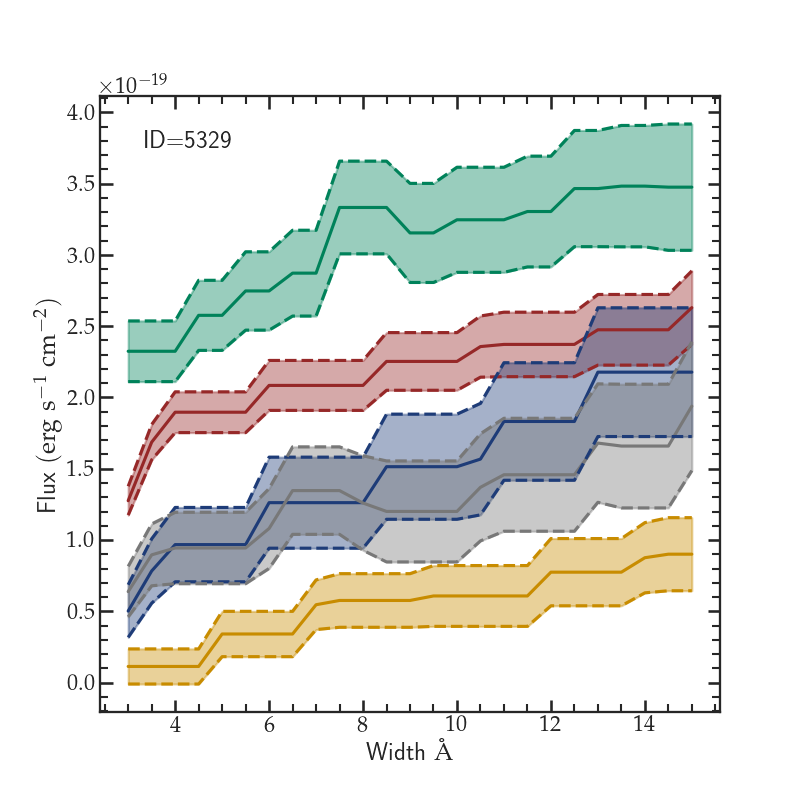

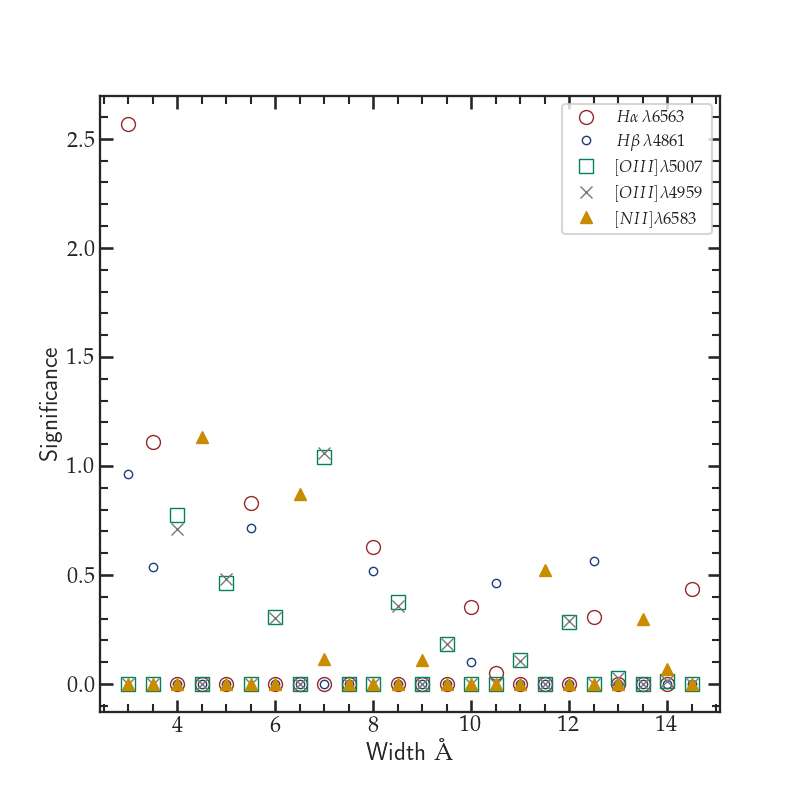

In [40]:
plot_variation_significance(8)

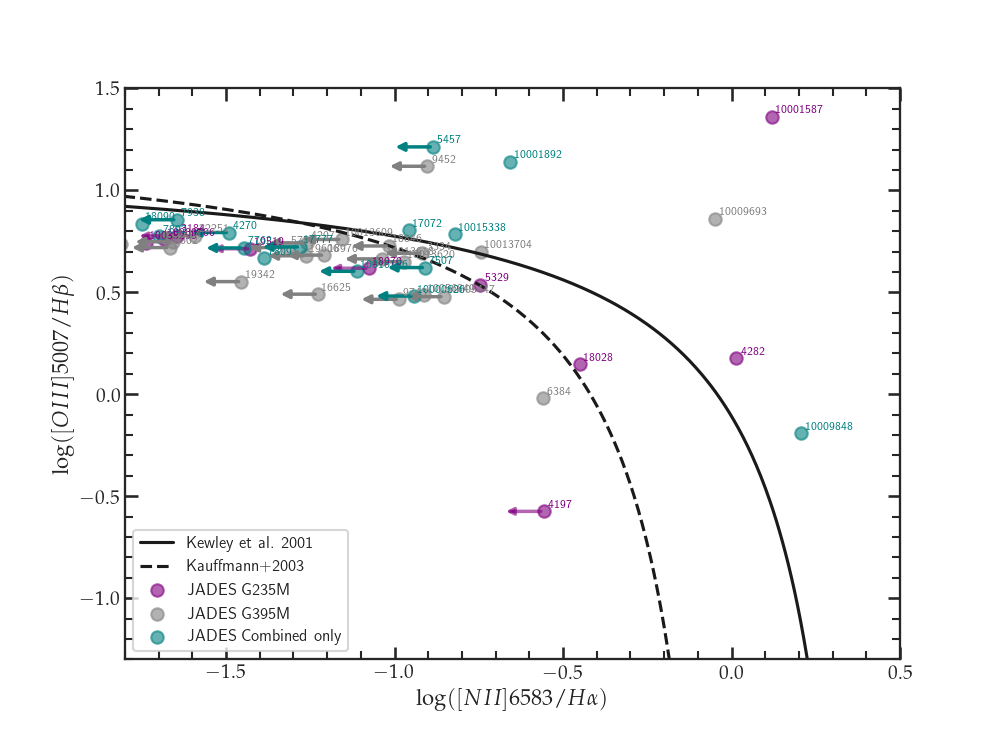

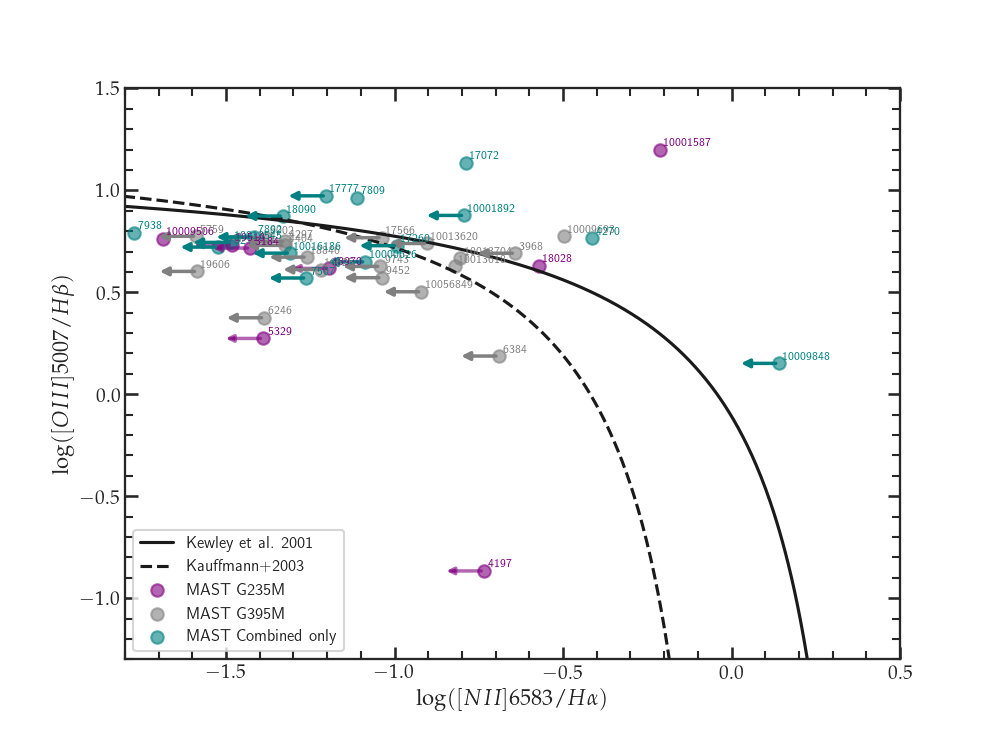

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#================= Plot Settings =================#
# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')


sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": False,
    })


#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes


def plot_bpt_combined(source='MAST', arrows=True, labels=False, save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_g235m = pd.read_csv('./Output_data/Line_fluxes_g235m_v5_optimal.tsv', sep='\t')
    df_g395m = pd.read_csv('./Output_data/Line_fluxes_g395m_v5_optimal.tsv', sep='\t')
    df_combn = pd.read_csv('./Output_data/Line_fluxes_combined_v5_optimal.tsv', sep='\t')

    if source == 'MAST':
        suffix = 'MAST'
        label_prefix = 'MAST'
        save_name = './Output_data/BPT_diagram_mast.pdf'
    elif source == 'JADES':
        suffix = 'JADES'
        label_prefix = 'JADES'
        save_name = './Output_data/BPT_diagram_jades.pdf'
    else:
        raise ValueError("Source must be 'MAST' or 'JADES'")

    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols_g235m = [col for col in df_g235m.columns if suffix in col]
    df_g235m_sub = df_g235m[['ID', 'redshift'] + cols_g235m].copy()

    cols_g395m = [col for col in df_g395m.columns if suffix in col]
    df_g395m_sub = df_g395m[['ID', 'redshift'] + cols_g395m].copy()

    cols_combn = [col for col in df_combn.columns if suffix in col]
    df_combn_sub = df_combn[['ID', 'redshift'] + cols_combn].copy()

    plot_cols = [
        f'Flux ([OIII]5007) {suffix}',
        f'Flux (Hb 4861) {suffix}',
        f'Flux ([NII]6583) {suffix}',
        f'Flux (Ha 6563) {suffix}',
        f'F_err([NII]6583) {suffix}',
    ]

    # Keep only rows with valid flux measurements in the G235M and G395M plots
    df_g235m_sub = df_g235m_sub.dropna(subset=plot_cols)
    df_g395m_sub = df_g395m_sub.dropna(subset=plot_cols)

    # Only keep combined rows whose IDs are not already in the valid G235M or G395M samples
    existing_ids = pd.Index(df_g235m_sub['ID']).append(pd.Index(df_g395m_sub['ID'])).unique()
    df_combn_only = df_combn_sub[~df_combn_sub['ID'].isin(existing_ids)].copy()

    # Require all four line fluxes for the combined-only sample
    df_combn_only = df_combn_only.dropna(subset=plot_cols)

    # Extract the specific columns of interest
    flux_o3_g235m = df_g235m_sub[f'Flux ([OIII]5007) {suffix}']
    flux_hb_g235m = df_g235m_sub[f'Flux (Hb 4861) {suffix}']
    flux_n2_g235m = df_g235m_sub[f'Flux ([NII]6583) {suffix}']
    flux_ha_g235m = df_g235m_sub[f'Flux (Ha 6563) {suffix}']

    flux_o3_g395m = df_g395m_sub[f'Flux ([OIII]5007) {suffix}']
    flux_hb_g395m = df_g395m_sub[f'Flux (Hb 4861) {suffix}']
    flux_n2_g395m = df_g395m_sub[f'Flux ([NII]6583) {suffix}']
    flux_ha_g395m = df_g395m_sub[f'Flux (Ha 6563) {suffix}']

    ferr_n2_g395m = df_g395m_sub[f'F_err([NII]6583) {suffix}']

    #================= Calculations for the plot =================#
    # Calculate log ratios (x and y for scatter plot)
    y235 = np.log10(flux_o3_g235m / flux_hb_g235m)
    x235 = np.log10(flux_n2_g235m / flux_ha_g235m)

    y395 = np.log10(flux_o3_g395m / flux_hb_g395m)
    x395 = np.log10(flux_n2_g395m / flux_ha_g395m)

    ferr_n2_g235m = df_g235m_sub[f'F_err([NII]6583) {suffix}']
    g235m_left_arrow = flux_n2_g235m < ferr_n2_g235m

    ferr_n2_g395m = df_g395m_sub[f'F_err([NII]6583) {suffix}']
    g395_left_arrow = flux_n2_g395m < ferr_n2_g395m

    flux_o3_combn = df_combn_only[f'Flux ([OIII]5007) {suffix}']
    flux_hb_combn = df_combn_only[f'Flux (Hb 4861) {suffix}']
    flux_n2_combn = df_combn_only[f'Flux ([NII]6583) {suffix}']
    flux_ha_combn = df_combn_only[f'Flux (Ha 6563) {suffix}']
    ferr_n2_combn = df_combn_only[f'F_err([NII]6583) {suffix}']
    combn_left_arrow = flux_n2_combn < ferr_n2_combn

    ycombn = np.log10(flux_o3_combn / flux_hb_combn)
    xcombn = np.log10(flux_n2_combn / flux_ha_combn)

    # Kewley maximum starburst line-
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #================= plot function =================# 
    plt.figure(figsize=(10, 7.4165))
    #plt.figure(figsize=(10, 6.18))


    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

    plt.scatter(x235, y235, alpha=0.6, color='purple', label=f'{label_prefix} G235M')
    plt.scatter(x395, y395, alpha=0.6, color='grey', label=f'{label_prefix} G395M')
    plt.scatter(xcombn, ycombn, alpha=0.6, color='teal', label=f'{label_prefix} Combined only')

    plt.xlim(-1.8, 0.5)
    plt.ylim(-1.3, 1.5)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()

    #Add arrows of upper limits for [NII]6583 fluxes where the flux is less than the error
    if arrows:
        for x, y in zip(x235[g235m_left_arrow], y235[g235m_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='purple', alpha=0.6, lw=2.5, mutation_scale=10),
                va='center'
            )

        for x, y in zip(x395[g395_left_arrow], y395[g395_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='grey', lw=2.5, mutation_scale=12),
                va='center'
            )

        for x, y in zip(xcombn[combn_left_arrow], ycombn[combn_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='teal', lw=2.5, mutation_scale=12),
                va='center'
            )

    if labels:
        for x, y, obj_id in zip(x235, y235, df_g235m_sub['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='purple'
            )

        for x, y, obj_id in zip(x395, y395, df_g395m_sub['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='grey'
            )

        for x, y, obj_id in zip(xcombn, ycombn, df_combn_only['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='teal'
            )

    plt.legend(loc='lower left')
    
    if save:
        plt.savefig(save_name, bbox_inches='tight')
    
    if show:
        plt.show()

#====================================================================#
#====================================================================#
plot_bpt_combined(source='JADES', save=False, labels=True)
plot_bpt_combined(source='MAST', save=False, labels=True)